# Tutorial on how to use Directional DIC to measuere displacement from videos
Unidirectional translation identification as introduced in:
Masmeijer T., Habtour E., Zaletelj, K., & Slavič, J., (2024). **Directional DIC method with automatic feature selection**. *MSSP*.
"https://doi.org/10.1016/j.ymssp.2024.112080".

The implementation is based on the Lucas-Kanade method using least-squares iterative optimization with the Zero Normalized
Cross Correlation optimization criterion.

In [1]:
import os
import sys
sys.path.insert(0, os.path.realpath('__file__'))

import numpy as np
import matplotlib.pyplot as plt
import pickle
import pyidi

Load the video

In [2]:
filename = '../data/data_synthetic.cih'
video = pyidi.VideoReader(filename)

In [3]:
print(f"N images: {video.N}")
print(f"Image height: {video.image_height}")
print(f"Image width: {video.image_width}")

N images: 101
Image height: 128
Image width: 256


In [4]:
%matplotlib qt
import matplotlib.animation as animation

def play_video(frame_range = None, interval=30, points = None, ij_counter = (0.65, 0.05)):
    
    """
    Plays the video from the given video object.
    Args:
        frame_range (range object): The range of frames to play.
        interval (int): The interval between frames in milliseconds.
        points (ndarray): Optional tracked points to plot on the video.
        ij_counter (tuple): The position of the frame counter.
    """
    if frame_range is None:
        frame_range = range(0, video.N)
    fig, ax = plt.subplots()
    im = ax.imshow(video.get_frame(frame_range[0]), cmap='gray')
    text = ax.text(ij_counter[0], ij_counter[1], '', transform=ax.transAxes, color='black', ha='right', va='bottom')

    if points is not None:
        pts = ax.plot(points[:,0,1], points[:,0,0], 'r.')

    def update(i):
        im.set_data(video.get_frame(i))
        text.set_text(f'Frame {i}')
        if points is not None:
            pts[0].set_data(points[:,i,1], points[:,i,0])
        return im, text

    ani = animation.FuncAnimation(fig, update, frames=frame_range, interval=interval)
    plt.show()
    return ani

ani = play_video(range(1, video.N))

## `Lucas Kanade` method as a reference

In [5]:
tol = 1e-8
roi_size = (5,5)
idi_lk = pyidi.LucasKanade(video)
idi_lk.configure(reference_image = (0,100), resume_analysis = False, tol=tol, roi_size=roi_size)
reference_image = idi_lk._set_reference_image(video, idi_lk.reference_image)

# Select the highest gradient points
Gi, Gj = np.gradient(reference_image)
G = np.sqrt(Gi**2 + Gj**2)
highest_points = np.argpartition(G.flatten(), -10)[-10:]
arguments = np.unravel_index(highest_points, G.shape)

Visualize the selected points

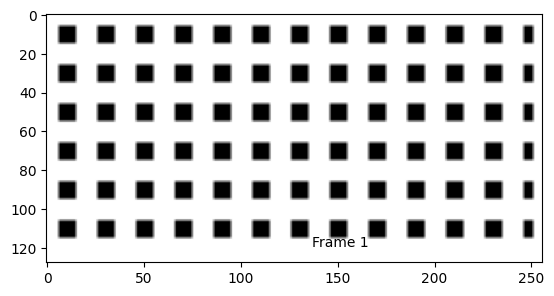

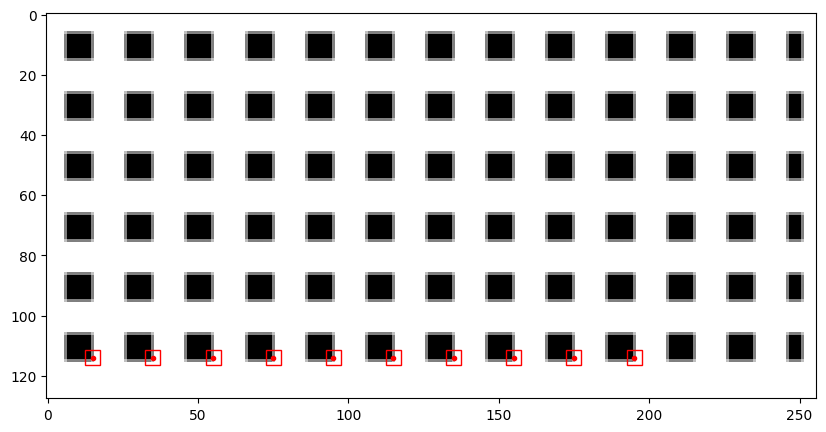

In [6]:
%matplotlib inline
points2d = np.array(arguments).T
idi_lk.set_points(points2d)
idi_lk.show_points()

Compoute displacements

In [7]:
displacementes_2d = idi_lk.get_displacements(processes=2, autosave=False)

Output()

--- Starting new analysis ---
 
Computation start: 2026-04-23 07:33:36.360774


Computation duration: 00:00:12.81


## `Directional - Lucas Kanade` method

In [8]:
idi_dlk = pyidi.DirectionalLucasKanade(video)

Define the direction of motion

In [9]:
tol = 1e-8
roi_size = (5,5)

# set a single direction for all points, ...
dij = (0.5, 0.5) 
# ... or set a direction for each point.
dij = np.array([[0.0, 1], 
                [0.1, 1],
                [0.2, 1], 
                [0.3, 1], 
                [0.4, 1], 
                [0.5, 1], 
                [0.6, 1], 
                [0.7, 1], 
                [0.8, 1], 
                [0.9, 1], ])

# Set directions in configure or set_directions function
idi_dlk.configure(reference_image = (0,100), dij=dij, resume_analysis = False, tol=tol,roi_size=roi_size)
idi_dlk.set_directions(dij)

reference_image = idi_dlk._set_reference_image(video, idi_dlk.reference_image)
Gi, Gj = np.gradient(reference_image)
G = np.sqrt(Gi**2 + Gj**2)
highest_points = np.argpartition(G.flatten(), -10)[-10:]
arguments = np.unravel_index(highest_points, G.shape)

In [10]:
%matplotlib qt
points1d = np.array(arguments).T
idi_dlk.set_points(points1d)
idi_dlk.show_points()

Compute displacements

In [11]:
displacements = idi_dlk.get_displacements(processes=2, autosave=False)

Output()

--- Starting new analysis ---
 
Computation start: 2026-04-23 07:33:49.930251


Computation duration: 00:00:12.73


## Comparison
Note, use D-DIC with care. Any motion perpendicular to d can affect the results. See paper for more info

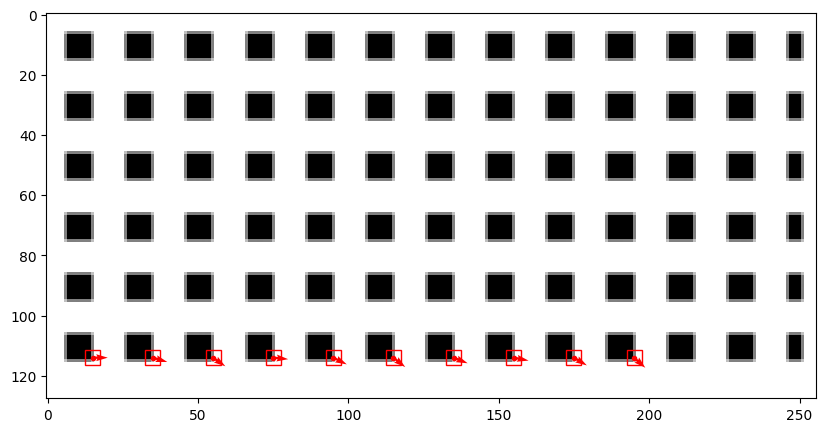

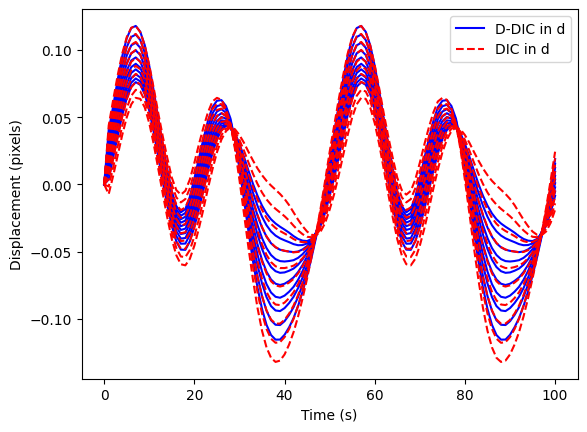

In [12]:
%matplotlib inline
t_vec = np.arange(0, len(displacements[0])) * video.fps

if dij.ndim == 1:
    dij = np.ones_like(points1d)*dij

fig, ax = plt.subplots()
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement (pixels)')
for point, dijk in zip(displacements, dij):
    ax.plot(t_vec, point[:,0]*dijk[0] + point[:,1]*dijk[1],'b', label=f'D-DIC in d')
for point, dijk in zip(displacementes_2d, dij):
    ax.plot(t_vec, point[:,0]*dijk[0] + point[:,1]*dijk[1], 'r--', label=f'DIC in d')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.show()

In [13]:
%matplotlib qt
td2d     = displacementes_2d +  points2d.reshape(len(points2d),1,2)
td1d     = displacements +  points1d.reshape(len(points1d),1,2)
combined_td = np.concatenate((td1d, td2d), axis=0)
ani = play_video(range(1,video.N), points=combined_td)